In [1]:
import pandas as pd
import torch
from PIL import Image

In [2]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
from datasets import load_dataset

crisismmd = load_dataset(
    "QCRI/CrisisMMD",
    "informative"
)

c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
crisismmd

DatasetDict({
    train: Dataset({
        features: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image_path', 'image', 'label'],
        num_rows: 13608
    })
    dev: Dataset({
        features: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image_path', 'image', 'label'],
        num_rows: 2237
    })
    test: Dataset({
        features: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image_path', 'image', 'label'],
        num_rows: 2237
    })
})

In [5]:
sample = crisismmd["train"][0]

print("Tweet:")
print(sample["tweet_text"])

print("\nLabel:")
print(sample["label"])

print("\nEvent:")
print(sample["event_name"])

print("\nImage type:")
print(type(sample["image"]))

Tweet:
RT @Cal_OES: PLS SHARE: Weâ€™re capturing wildfire response, recovery info here: https://t.co/r89LKpjLPj https://t.co/HiA1oQF2Ax

Label:
0

Event:
california_wildfires

Image type:
<class 'NoneType'>


In [6]:
print(crisismmd["train"].data)

MemoryMappedTable
event_name: string
tweet_id: string
image_id: string
tweet_text: string
image_path: string
image: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
label: int64
----
event_name: [["california_wildfires","california_wildfires","california_wildfires","california_wildfires","california_wildfires",...,"california_wildfires","california_wildfires","california_wildfires","california_wildfires","california_wildfires"],["california_wildfires","california_wildfires","california_wildfires","california_wildfires","california_wildfires",...,"srilanka_floods","srilanka_floods","srilanka_floods","srilanka_floods","srilanka_floods"],...,["hurricane_harvey","hurricane_harvey","hurricane_irma","hurricane_harvey","hurricane_irma",...,"hurricane_irma","mexico_earthquake","hurricane_irma","hurricane_irma","california_wildfires"],["hurricane_harvey","california_wildfires","hurricane_maria","hurricane_maria","hurricane_irma","hurricane_harvey","hurricane_

In [7]:
print(crisismmd["train"].data.column_names)

['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image_path', 'image', 'label']


In [8]:
from pathlib import Path

crisis_path = Path(
    r"C:\Users\gorbe\OneDrive\Desktop\COding\PROJECTS\social-media-analytics\data\raw\CrisisMMD_v2.0"
)

print(crisis_path.exists())
print(list(crisis_path.iterdir())[:10])

True
[WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/.DS_Store'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/._.DS_Store'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/._Readme.txt'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/annotations'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/crisismmd_datasplit_all.zip'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/data_image'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/json'), WindowsPath('C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/raw/CrisisMMD_v2.0/Readme.txt')]


In [9]:
image_root = crisis_path / "data_image"

print(image_root.exists())

True


In [10]:
from pathlib import Path
from PIL import Image

def get_image_path(relative_path):
    relative_path = Path(relative_path)

    if relative_path.parts[0] == "data_image":
        relative_path = Path(*relative_path.parts[1:])

    return image_root / relative_path

In [11]:
sample_path = get_image_path(sample["image_path"])

print(sample_path)
print(sample_path.exists())

C:\Users\gorbe\OneDrive\Desktop\COding\PROJECTS\social-media-analytics\data\raw\CrisisMMD_v2.0\data_image\california_wildfires\10_10_2017\917791291823591425_0.jpg
True


In [12]:
image = Image.open(sample_path)

print(type(image))
print(image.size)

<class 'PIL.JpegImagePlugin.JpegImageFile'>
(640, 480)


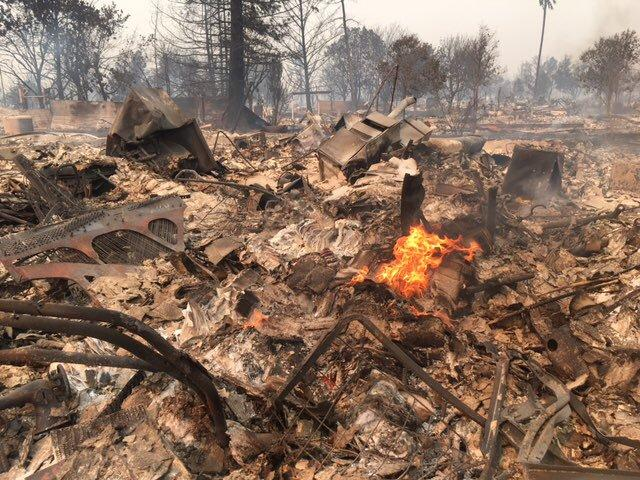

In [13]:
from IPython.display import display

display(image)

In [14]:
mmd_train_df = crisismmd["train"].to_pandas()
mmd_test_df = crisismmd["test"].to_pandas()

In [15]:
mmd_train_df["local_image_path"] = mmd_train_df["image_path"].apply(
    get_image_path
)

mmd_test_df["local_image_path"] = mmd_test_df["image_path"].apply(
    get_image_path
)

In [16]:
print(
    mmd_train_df["local_image_path"].apply(Path.exists).mean()
)
print(
    mmd_test_df["local_image_path"].apply(Path.exists).mean()
)

1.0
1.0


In [17]:
print(mmd_train_df["label"].value_counts())

label
0    8341
1    5267
Name: count, dtype: int64


In [18]:
from torchvision.models import resnet50, ResNet50_Weights

In [19]:
weights = ResNet50_Weights.DEFAULT

image_model = resnet50(weights=weights)

print(image_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [20]:
weights = ResNet50_Weights.DEFAULT

image_transform = weights.transforms()

print(image_transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [21]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cuda


In [22]:
import torch.nn as nn

image_model.fc = nn.Identity()
image_model = image_model.to(device)
image_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [23]:
def extract_image_features(image_path):
    image = Image.open(image_path).convert("RGB")

    image_tensor = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = image_model(image_tensor)

    return features.squeeze().cpu().numpy()

In [24]:
features = extract_image_features(
    mmd_train_df["local_image_path"].iloc[0]
)

print(features.shape)

(2048,)


In [25]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [26]:
class CrisisImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        path = self.dataframe.loc[index, "local_image_path"]
        label = int(self.dataframe.loc[index, "label"])

        image = Image.open(path).convert("RGB")
        image = self.transform(image)

        return image, label

In [27]:
image_dataset = CrisisImageDataset(
    mmd_train_df,
    image_transform
)

image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [28]:
all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in image_loader:
        images = images.to(device)

        features = image_model(images)

        all_features.append(
            features.cpu().numpy()
        )

        all_labels.append(
            labels.numpy()
        )

c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [29]:
image_features = np.concatenate(all_features)
image_labels = np.concatenate(all_labels)

print("Features:", image_features.shape)
print("Labels:", image_labels.shape)

Features: (13608, 2048)
Labels: (13608,)


In [30]:
from sklearn.model_selection import train_test_split

X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    image_features,
    image_labels,
    test_size=0.20,
    random_state=42,
    stratify=image_labels
)

In [31]:
from sklearn.linear_model import LogisticRegression

image_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [32]:
image_classifier.fit(
    X_img_train,
    y_img_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [33]:
y_img_pred = image_classifier.predict(X_img_test)

In [34]:
from sklearn.metrics import accuracy_score, classification_report

image_accuracy = accuracy_score(
    y_img_test,
    y_img_pred
)

print("Image Accuracy:", image_accuracy)

print(
    classification_report(
        y_img_test,
        y_img_pred,
        target_names=["informative", "not_informative"]
    )
)

Image Accuracy: 0.710139603232917
                 precision    recall  f1-score   support

    informative       0.76      0.77      0.76      1668
not_informative       0.63      0.62      0.62      1054

       accuracy                           0.71      2722
      macro avg       0.69      0.69      0.69      2722
   weighted avg       0.71      0.71      0.71      2722



In [35]:
mmd_train_df[["tweet_text", "label"]].head()

,tweet_text,label
0,RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...,0
1,RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...,1
2,RT @KAKEnews: California wildfires destroy mor...,0
3,RT @KAKEnews: California wildfires destroy mor...,0
4,RT @KAKEnews: California wildfires destroy mor...,0


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

mmd_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

In [37]:
mmd_text_features = mmd_tfidf.fit_transform(
    mmd_train_df["tweet_text"].fillna("")
)

In [38]:
print(mmd_text_features.shape)
print(image_features.shape)

(13608, 10000)
(13608, 2048)


In [39]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(mmd_train_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=mmd_train_df["label"]
)

print("Train:", len(train_idx))
print("Test:", len(test_idx))

Train: 10886
Test: 2722


In [40]:
train_text = mmd_train_df.iloc[train_idx]["tweet_text"].fillna("")
test_text = mmd_train_df.iloc[test_idx]["tweet_text"].fillna("")

In [41]:
mmd_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

X_text_train = mmd_tfidf.fit_transform(train_text)
X_text_test = mmd_tfidf.transform(test_text)

In [42]:
X_image_train = image_features[train_idx]
X_image_test = image_features[test_idx]

y_mm_train = mmd_train_df.iloc[train_idx]["label"].to_numpy()
y_mm_test = mmd_train_df.iloc[test_idx]["label"].to_numpy()

In [43]:
print("Text train:", X_text_train.shape)
print("Text test:", X_text_test.shape)

print("Image train:", X_image_train.shape)
print("Image test:", X_image_test.shape)

Text train: (10886, 10000)
Text test: (2722, 10000)
Image train: (10886, 2048)
Image test: (2722, 2048)


In [44]:
from scipy.sparse import hstack
X_mm_train = hstack([
    X_text_train,
    X_image_train
])

X_mm_test = hstack([
    X_text_test,
    X_image_test
])

In [45]:
print("Multimodal train:", X_mm_train.shape)
print("Multimodal test:", X_mm_test.shape)

Multimodal train: (10886, 12048)
Multimodal test: (2722, 12048)


In [46]:
multimodal_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [47]:
multimodal_classifier.fit(
    X_mm_train,
    y_mm_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [48]:
y_mm_pred = multimodal_classifier.predict(X_mm_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

mm_accuracy = accuracy_score(
    y_mm_test,
    y_mm_pred
)

print("Multimodal Accuracy:", mm_accuracy)

print(
    classification_report(
        y_mm_test,
        y_mm_pred,
        target_names=["informative", "not_informative"]
    )
)

Multimodal Accuracy: 0.7490815576781779
                 precision    recall  f1-score   support

    informative       0.79      0.80      0.80      1668
not_informative       0.68      0.66      0.67      1054

       accuracy                           0.75      2722
      macro avg       0.74      0.73      0.73      2722
   weighted avg       0.75      0.75      0.75      2722



In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_mm_test,
        y_mm_pred,
        target_names=["informative", "not_informative"]
    )
)

                 precision    recall  f1-score   support

    informative       0.79      0.80      0.80      1668
not_informative       0.68      0.66      0.67      1054

       accuracy                           0.75      2722
      macro avg       0.74      0.73      0.73      2722
   weighted avg       0.75      0.75      0.75      2722



In [51]:
text_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

text_classifier.fit(
    X_text_train,
    y_mm_train
)

y_text_mm_pred = text_classifier.predict(X_text_test)

text_mm_accuracy = accuracy_score(
    y_mm_test,
    y_text_mm_pred
)

print("CrisisMMD Text-only Accuracy:", text_mm_accuracy)

CrisisMMD Text-only Accuracy: 0.7373254959588538


In [52]:
import json

multimodal_results = {
    "image_only_accuracy": 0.710,
    "text_only_accuracy": 0.737,
    "text_image_accuracy": 0.749,
    "text_image_macro_f1": 0.73
}

with open("../models/multimodal_results.json", "w") as f:
    json.dump(multimodal_results, f, indent=4)

In [53]:
def predict_multimodal(text, image_path):
    # Text features
    text_features = mmd_tfidf.transform([text])

    # Image features
    image_feature = extract_image_features(image_path)
    image_feature = image_feature.reshape(1, -1)

    # Combine text + image
    combined_features = hstack([
        text_features,
        image_feature
    ])

    # Predict
    prediction = multimodal_classifier.predict(
        combined_features
    )[0]

    probabilities = multimodal_classifier.predict_proba(
        combined_features
    )[0]

    confidence = probabilities[prediction]

    return {
        "prediction": int(prediction),
        "confidence": round(float(confidence), 4)
    }

In [54]:
result = predict_multimodal(
    sample["tweet_text"],
    sample_path
)

result

{'prediction': 0, 'confidence': 0.9986}

In [55]:
import joblib

joblib.dump(
    image_classifier,
    "../models/image_classifier.pkl"
)

joblib.dump(
    mmd_tfidf,
    "../models/mmd_tfidf.pkl"
)

joblib.dump(
    multimodal_classifier,
    "../models/multimodal_classifier.pkl"
)

['../models/multimodal_classifier.pkl']